# NESS phase maps and one picked state (EI_bins)
Phase maps over (T1, T2) of Delta, the Hartree gap, the indirect gap of the
quasiparticle bands and the imbalance n_a - n_b; then for one picked point
the bare, Hartree and quasiparticle bands along Gamma-X-M-Gamma (coloured by
the transition rate through each state), n_alpha and n_beta over the BZ,
and the occupations against Fermi-Dirac with the effective temperatures.

In [68]:
import os
import warnings
from pathlib import Path
import tqdm.notebook as tqdm 

import numpy as np
import yaml
import colormaps as cmaps
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from scipy.special import expit

import EI_bins as eb
from EI_bins.eq import chem_pot
from EI_bins.kernel import cells, rates, spec_line
from utils.cosmetics import SET1_LIST, apply_plt_style
from utils.logger import logger, tqdm_bar
from utils.plotting_utils import Plotter, add_legend, color_map, format_ax

ROOT = Path(os.environ.get("EI_ROOT", "/home/kzeleznikar/IJS-F1/Koda/EI_baths"))
CFG = ROOT / "config" / "config_phonons.yaml"

apply_plt_style()
pt = Plotter(show=True, close=False)
SOLVE, SWEEP = eb.solve_ness_jax, eb.sweep_jax      # eb.solve_ness_jax, eb.sweep_jax on the GPU

T1N, T2N = 2.0, 1.05                         # picked point, in units of Tc
PREFER = "ordered"     # map: follow the ordered branch; "normal" is faster (hysteresis)


from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png", dpi=300)

In [69]:
with CFG.open("r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

bd = eb.Band(**cfg["model"]["band"]["pars"])
p = eb.MF(**cfg["model"]["mean_field"])
bq = dict(cfg["open_system"]["bath"]["pars"])
tg = cfg.get("scan", {}).get("temperature", {})
tn = np.linspace(tg.get("min_ratio", 0.01), tg.get("max_ratio", 2.0), tg.get("nt", 15))

# equilibrium scales on a fine shell grid, Tc by bisection on the ordered branch
ref = eb.make_shells(131)
s0 = eb.solve_eq(ref, bd, p, 1.0e-3, 1.0, -0.6)
d0, m0 = s0.d, s0.m
lo, hi = 0.05, 2.0
for _ in range(40):
    t = 0.5 * (lo + hi)
    e = eb.solve_eq(ref, bd, p, t, 0.5 * d0, m0)
    lo, hi = (t, hi) if (e.ok and e.d > 1.0e-4) else (lo, t)
tc = 0.5 * (lo + hi)
logger.info("Delta_0 = %.8f, m_0 = %.8f, T_c = %.8f", d0, m0, tc)


# def bths(t1, t2):
#     """The two config baths at temperatures t1 and t2."""
#     return (eb.from_cfg(t1, bq, name="bath_1"), eb.from_cfg(t2, bq, name="bath_2"))

# block 0: two constant baths with their own frequencies
W1, W2 = 2.2, 1.8                         # omega_1, omega_2


def bths(t1, t2):
    """Config baths at t1, t2 with frequencies W1, W2."""
    return (eb.from_cfg(t1, {**bq, "w0": W1}, name="bath_1"),
            eb.from_cfg(t2, {**bq, "w0": W2}, name="bath_2"))


NT = 4
ns_ = eb.auto_ns(bd, min(d0, tc, W1, W2))
sh = eb.make_sectors(ns_, NT) if NT > 1 else eb.make_shells(ns_)
kn = eb.kernels(sh, bd, bths(tc, tc), cache=ROOT / "kernels")  # one Kern per bath

# shells and kernels do not depend on the temperatures: build them once
# sh = eb.make_shells(eb.auto_ns(bd, min(d0, tc, bq.get("w0", 1.0))))
# kn = eb.kernels(sh, bd, bths(tc, tc), cache=ROOT / "kernels")
bl = (r"\alpha", r"\beta")
w2 = np.tile(sh.w, 2)
logger.info("ns = %d, frequency bins = %d", sh.ns, kn[0].om.size)

[21:21:54] [INFO    ] Delta_0 = 1.00005410, m_0 = -0.68433759, T_c = 0.53523672
[21:21:54] [INFO    ] ns = 244, frequency bins = 1


## Bands and gaps
Bare bands ea, eb; Hartree bands ea + h (n_b - 1/2), eb + h (n_a - 1/2)
(eah, ebh of ei_unified shifted by -h/2, the energy zero of the solver); and the
quasiparticle bands E_alpha, E_beta. All depend on k only through s, so the
extrema are taken on a fine s grid. Hartree gap: signed, at Gamma (s = 2).
Indirect gap: min E_alpha - max E_beta over the BZ.

In [70]:
sf = np.linspace(-2.0, 2.0, 4001)           # fine s grid for band extrema


def bands(s, d, m):
    """Bare, Hartree and quasiparticle bands at shell values s."""
    ba, bb = bd.bare(s)
    c0 = 0.5 * p.h * (p.n - 1.0)
    ha = ba + c0 - 0.5 * p.h * m
    hb = bb + c0 + 0.5 * p.h * m
    xi, av = 0.5 * (ha - hb), 0.5 * (ha + hb)
    ek = np.hypot(xi, d)
    return (ba, bb), (ha, hb), (av + ek, av - ek)


def gaps(d, m):
    """Hartree gap at Gamma and indirect quasiparticle gap."""
    _, (ha, hb), (qa, qb) = bands(sf, d, m)
    return ha[-1] - hb[-1], qa.min() - qb.max()

## Phase maps
Row by row at fixed T2: continuation in T1 from T1 = T2 (exact equilibrium)
upwards, mirrored to T1 < T2. With PREFER = "ordered" the ordered branch is
followed as long as it exists (like increasing T1 slowly); where it ends,
the normal state is taken if it is stable against order (pair_chi < 1).
Points that did not converge are left blank.

In [71]:
ta = tn * tc
nt = tn.size
keys = ("d", "m", "gh", "gi", "ok")
mp = {q: np.full((nt, nt), np.nan) for q in keys}
sols = {}

# speed settings: map tolerance, no per-point stability, short budgets
SK = dict(tol=1e-8, stab=False, nmax=15, fold=0.125)   # passed to every solve
SW = dict(prefer=PREFER, nfold=8, lfold=0.25)          # continuation budget


def ticked(fn, bar):
    """Bath function that advances bar by one per call (one call per point)."""
    def wrap(x):
        bar.update(1)
        return fn(x)
    return wrap


with warnings.catch_warnings():
    warnings.simplefilter("ignore")          # branch and block notices
    outer = tqdm_bar(range(nt), desc="diagonal", position=0)
    for j in outer:
        n_ = nt - j
        inner = tqdm_bar(total=2 * (n_ + 1), desc=f"T={tn[j]:.2f}",
                         position=1, leave=False)
        row = SWEEP(sh, bd, p, ticked(lambda x, t2=ta[j]: bths(x, t2), inner),
                    ta[j:], A=kn, **SW, **SK)
        col = SWEEP(sh, bd, p, ticked(lambda x, t1=ta[j]: bths(t1, x), inner),
                    ta[j:], A=kn, **SW, **SK)
        inner.close()

        for i, (sr, sc_) in enumerate(zip(row, col), start=j):
            for s, (a_, b_) in ((sr, (j, i)), (sc_, (i, j))):
                if s is sc_ and i == j:
                    continue                 # diagonal stored from the row only
                vals = (s.d, s.m, *gaps(s.d, s.m), float(s.ok))
                for q, v in zip(keys, vals):
                    mp[q][a_, b_] = v
                sols[(a_, b_)] = s
        outer.set_postfix(ok=int(np.nansum(mp["ok"])))

logger.info("not converged: %d of %d", int(np.sum(mp["ok"] < 1)), nt * nt)

diagonal:   0%|                         0/10 [00:00<?, ?it/s]

T=0.01:   0%|                         0/22 [00:00<?, ?it/s]

T=0.34:   0%|                         0/20 [00:00<?, ?it/s]

T=0.67:   0%|                         0/18 [00:00<?, ?it/s]

T=1.01:   0%|                         0/16 [00:00<?, ?it/s]

...

T=2.00:   0%|                         0/10 [00:00<?, ?it/s]

T=2.34:   0%|                         0/8 [00:00<?, ?it/s]

T=2.67:   0%|                         0/6 [00:00<?, ?it/s]

T=3.00:   0%|                         0/4 [00:00<?, ?it/s]

[21:27:14] [INFO    ] not converged: 0 of 100


In [72]:
# ta = tn * tc
# nt = tn.size
# keys = ("d", "m", "gh", "gi", "ok")
# mp = {q: np.full((nt, nt), np.nan) for q in keys}


# def ticked(fn, bar):
#     """Bath function that advances bar by one per call (one call per point)."""
#     def wrap(x):
#         bar.update(1)
#         return fn(x)
#     return wrap


# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")          # branch and block notices
#     outer = tqdm_bar(range(nt), desc="diagonal", position=0)
#     for j in outer:
#         n_ = nt - j
#         # sweep calls baths_of once more per sweep (kernel setup): 2 * (n_ + 1)
#         inner = tqdm_bar(total=2 * (n_ + 1), desc=f"T={tn[j]:.2f}",
#                          position=1, leave=False)
#         # row: T2 = ta[j] fixed, T1 from ta[j] upwards
#         row = SWEEP(sh, bd, p, ticked(lambda x, t2=ta[j]: bths(x, t2), inner),
#                     ta[j:], A=kn, prefer=PREFER)
#         # column: T1 = ta[j] fixed, T2 from ta[j] upwards
#         col = SWEEP(sh, bd, p, ticked(lambda x, t1=ta[j]: bths(t1, x), inner),
#                     ta[j:], A=kn, prefer=PREFER)
#         inner.close()

#         for i, (sr, sc_) in enumerate(zip(row, col), start=j):
#             for s, (a_, b_) in ((sr, (j, i)), (sc_, (i, j))):
#                 if s is sc_ and i == j:
#                     continue                 # diagonal stored from the row only
#                 vals = (s.d, s.m, *gaps(s.d, s.m), float(s.ok))
#                 for q, v in zip(keys, vals):
#                     mp[q][a_, b_] = v
#         outer.set_postfix(ok=int(np.nansum(mp["ok"])))

# logger.info("not converged: %d of %d", int(np.sum(mp["ok"] < 1)), nt * nt)
# # np.savez_compressed(ROOT / "phase_maps_bins.npz", tn=tn, d0=d0, tc=tc, **mp)

In [73]:
# normal branch at every point: pair_chi > 1 means the normal state is unstable
chi = np.full((nt, nt), np.nan)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for (a_, b_), s in tqdm_bar(sols.items(), desc="normal branch"):
        if not s.ok:
            continue
        bb = bths(ta[b_], ta[a_])            # T1 = ta[b_], T2 = ta[a_]
        sn = s if s.branch == "normal" else SOLVE(
            sh, bd, p, bb, A=kn, mu=s.mu, d=0.0, m=s.m, normal=True, direct=True, **SK)
        if not sn.ok:
            sn = SOLVE(sh, bd, p, bb, A=kn, normal=True, **SK)
        chi[a_, b_] = eb.pair_chi(sh, bd, p, sn) if sn.ok else np.nan

has_o = (mp["ok"] == 1.0) & (mp["d"] > 1e-3 * d0)
bist = has_o & (chi < 1.0)                  # ordered found, normal also stable
miss = ~has_o & (chi > 1.0)                 # order must exist but was not found
logger.info("bistable: %d, missed order: %d", int(bist.sum()), int(miss.sum()))
# np.savez_compressed(ROOT / "phase_maps_bins.npz", tn=tn, d0=d0, tc=tc, chi=chi, **mp)

normal branch:   0%|                         0/100 [00:00<?, ?it/s]

[21:29:30] [INFO    ] bistable: 1, missed order: 0


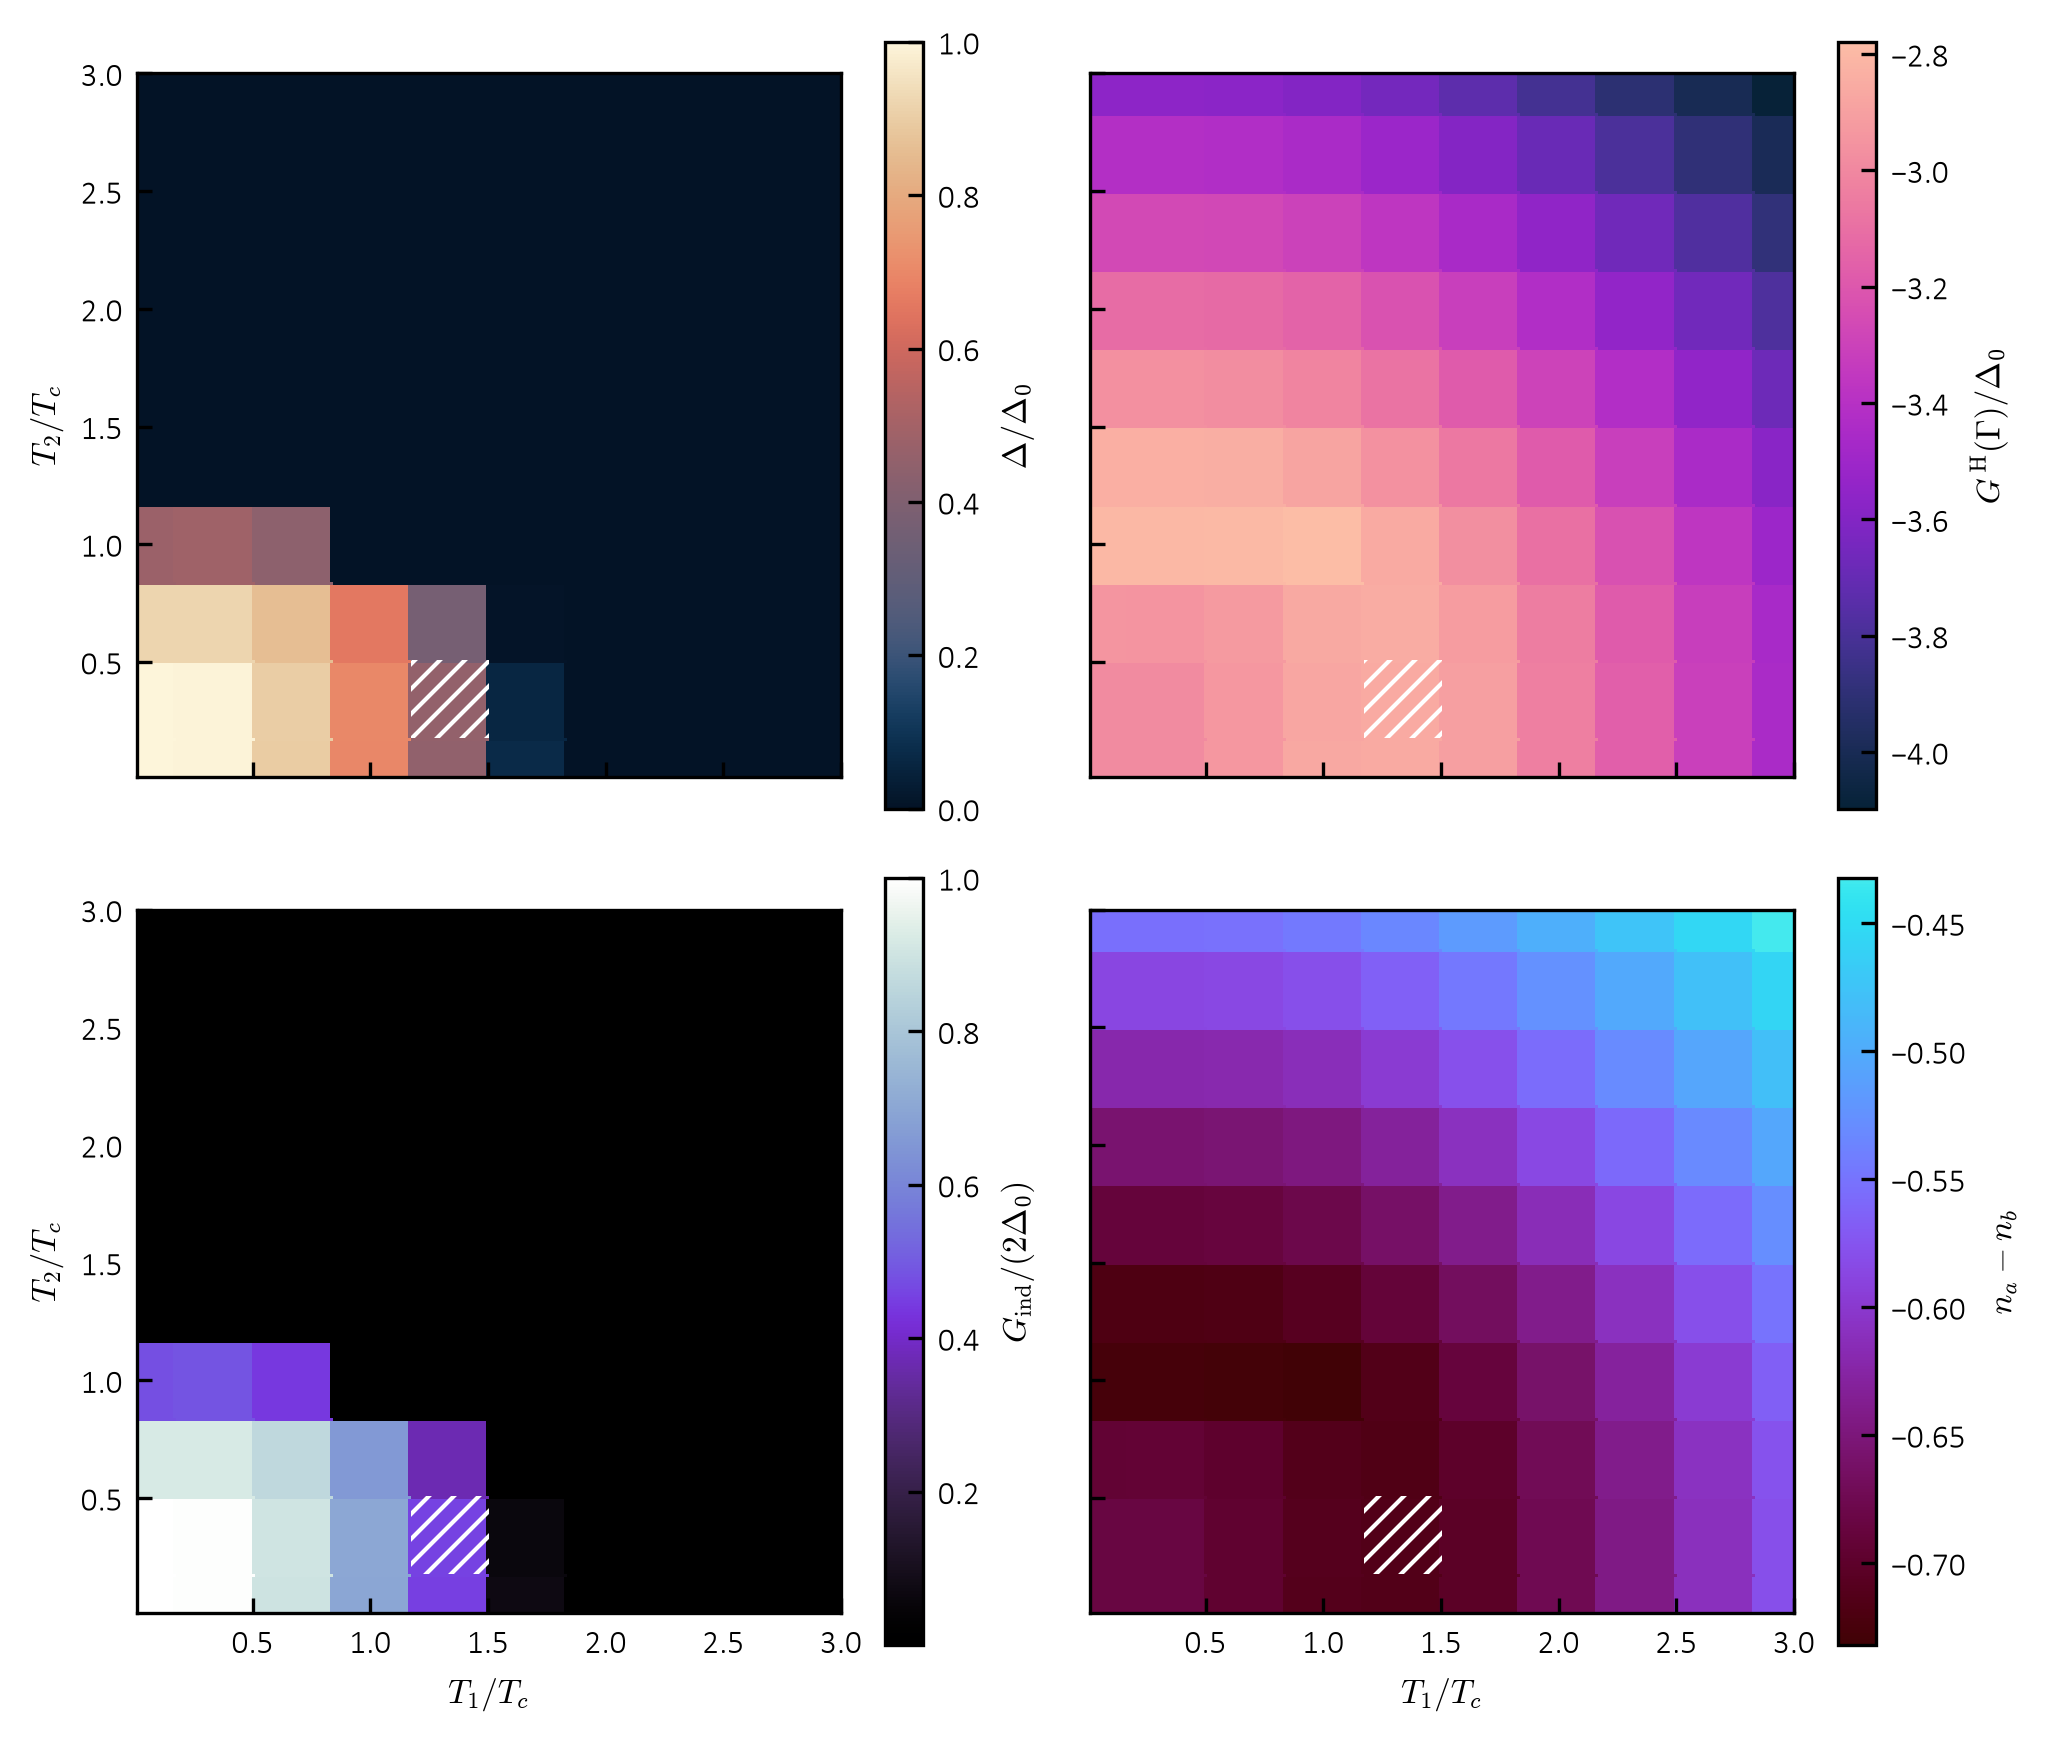

In [74]:
from matplotlib.patches import Rectangle


def edges(x):
    """Cell edges of a center grid."""
    mid = 0.5 * (x[1:] + x[:-1])
    return np.r_[2 * x[0] - mid[0], mid, 2 * x[-1] - mid[-1]]


def hatch(a, mask, pat, col="w"):
    """Hatch the map squares where mask is True."""
    ex = edges(tn)
    for j_, i_ in zip(*np.nonzero(mask)):
        a.add_patch(Rectangle((ex[i_], ex[j_]), ex[i_ + 1] - ex[i_], ex[j_ + 1] - ex[j_],
                              fill=False, hatch=pat, edgecolor=col, lw=0.0))


ok = np.where(mp["ok"] == 1.0, 1.0, np.nan)
maps = ((mp["d"] / d0, r"$\Delta/\Delta_0$", cmaps.lipari),
        (mp["gh"] / d0, r"$G^{\mathrm{H}}(\Gamma)/\Delta_0$", cmaps.bubblegum),
        (mp["gi"] / (2.0 * d0), r"$G_{\mathrm{ind}}/(2\Delta_0)$", cmaps.amethyst),
        (mp["m"], r"$n_a-n_b$", cmaps.gem))

with pt.figure(shape=(2, 2), h=1.7, w=2.0, sharex=True, sharey=True) as fg:
    for a, (z, lab_, cm_) in zip(fg.ax.ravel(), maps):
        im = color_map(a, tn, tn, z * ok, cmap=cm_)
        fg.colorbar(im, lab_, ax=a)
        hatch(a, bist, "////")               # bistable: ordered and normal both stable
        # hatch(a, miss, "xx", col="r")        # order missed by the sweep, re-solve
        format_ax(a, x=tn, grid=False)
        a.set_ylim(tn[0], tn[-1])
        a.set_aspect("equal")
    for a in fg.ax[1]:
        a.set_xlabel(r"$T_1/T_c$")
    for a in fg.ax[:, 0]:
        a.set_ylabel(r"$T_2/T_c$")

In [32]:
# ok = np.where(mp["ok"] == 1.0, 1.0, np.nan)
# maps = ((mp["d"] / d0, r"$\Delta/\Delta_0$", cmaps.lipari),
#         (mp["gh"] / d0, r"$G^{\mathrm{H}}(\Gamma)/\Delta_0$", cmaps.bubblegum),
#         (mp["gi"] / (2.0 * d0), r"$G_{\mathrm{ind}}/(2\Delta_0)$", cmaps.amethyst),
#         (mp["m"], r"$n_a-n_b$", cmaps.gem))

# with pt.figure(shape=(2, 2), h=1.7, w=2.0, sharex=True, sharey=True) as fg:
#     for a, (z, lab_, cm_) in zip(fg.ax.ravel(), maps):
#         im = color_map(a, tn, tn, z * ok, cmap=cm_)
#         fg.colorbar(im, lab_, ax=a)
#         a.plot([T1N], [T2N], marker="x", ms=4, color="w", mew=0.9)   # picked point
#         format_ax(a, x=tn, grid=False)
#         a.set_aspect("equal")
#     for a in fg.ax[1]:
#         a.set_xlabel(r"$T_1/T_c$")
#     for a in fg.ax[:, 0]:
#         a.set_ylabel(r"$T_2/T_c$")

## Picked point
NESS at (T1N, T2N) and the transition rate through every state:
(in + out flux of the cell) / (cell weight), i.e. transitions per state and
unit time, summed over both baths and all channels. In the steady state the
in and out parts are equal.

In [48]:
T1N, T2N =2.90, 1.0

In [49]:
ns_ = eb.auto_ns(bd, min(d0, tc, W1, W2)) * 6+1 
ns_

367

In [50]:
sh = eb.make_sectors(ns_, NT)
kn = eb.kernels(sh, bd, bths(tc, tc), cache=ROOT / "kernels")  # one Kern per bath

In [51]:
t1, t2 = T1N * tc, T2N * tc
bs = bths(t1, t2)
so = SOLVE(sh, bd, p, bs, A=kn)
# so = SOLVE(sh, bd, p, bs, A=kn, fold=0.25, nmax=12)
cl = cells(sh, bd, p, so.d, so.m)
logger.info("NESS: Delta/Delta_0 = %.4f, m = %.4f, %s, ok = %s",
            so.d / d0, so.m, so.branch, so.ok)

K = rates(cl, bs, kn)

[21:18:20] [INFO    ] NESS: Delta/Delta_0 = 0.2958, m = -0.3785, ordered, ok = True


In [52]:
w2 = np.tile(sh.w, 2)

In [53]:


n, h = expit(-so.mu).ravel(), expit(so.mu).ravel()   # particles, holes
n, h
fl = ((h * (K @ n) + n * (K.T @ h)) / w2).reshape(2, sh.ns)

findfont: Failed to find font weight normal, now using 300.
findfont: Failed to find font weight normal, now using 300.


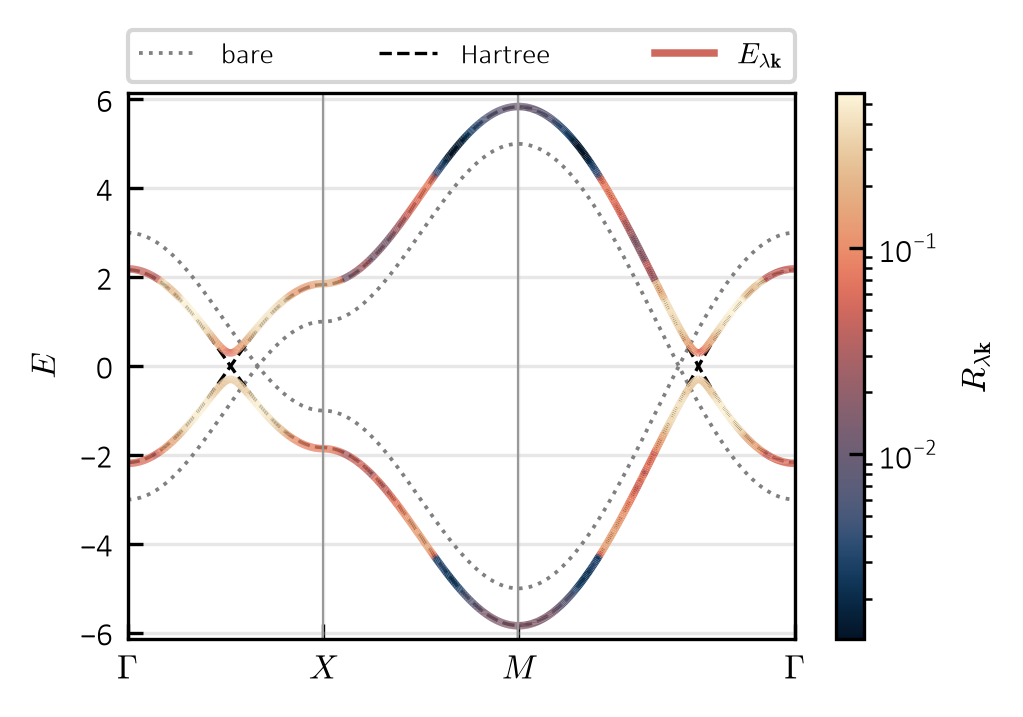

In [54]:
u = np.linspace(0.0, np.pi, 300)
kp = np.concatenate((np.stack((u, 0.0 * u), -1),                    # Gamma -> X
                     np.stack((np.full_like(u, np.pi), u), -1)[1:],  # X -> M
                     np.stack((u[::-1], u[::-1]), -1)[1:]))           # M -> Gamma
kd = np.r_[0.0, np.cumsum(np.linalg.norm(np.diff(kp, axis=0), axis=1))]
kt = [0.0, np.pi, 2.0 * np.pi, (2.0 + np.sqrt(2.0)) * np.pi]
kl = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]

sp = eb.s_of_k(kp)
(ba, bb), (ha, hb), (qa, qb) = bands(sp, so.d, so.m)
fp = fl[:, sh.label(np.cos(kp[:, 0]), np.cos(kp[:, 1]))]
fn = LogNorm(vmin=max(fl[fl > 0].min(), 1e-8 * fl.max()), vmax=fl.max())
cm = cmaps.lipari.with_extremes(bad="0.7")


def cline(a, x, y, c):
    """Line through (x, y), segment i coloured by c[i]."""
    xy = np.stack((x, y), -1)
    lc = LineCollection(np.stack((xy[:-1], xy[1:]), 1), cmap=cm, norm=fn, lw=1.8)
    lc.set_array(np.ma.masked_less_equal(c[:-1], 0.0))
    a.add_collection(lc)
    return lc


with pt.figure(h=0.7) as fg:
    a = fg.ax
    for y in (ba, bb):
        a.plot(kd, y, color="0.5", ls=":", lw=0.9)
    for y in (ha, hb):
        a.plot(kd, y, color="k", ls="--", lw=0.8)
    lc = cline(a, kd, qa, fp[0])
    cline(a, kd, qb, fp[1])
    ys = np.concatenate((ba, bb, ha, hb, qa, qb))
    a.set_ylim(ys.min() - 0.3, ys.max() + 0.3)
    for x in kt[1:-1]:
        a.axvline(x, color="0.6", lw=0.5)
    hd = [Line2D([], [], color="0.5", ls=":", lw=0.9, label="bare"),
          Line2D([], [], color="k", ls="--", lw=0.8, label="Hartree"),
          Line2D([], [], color=cm(0.6), lw=1.8, label=r"$E_{\lambda\mathbf{k}}$")]
    a.legend(handles=hd, bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left",
             mode="expand", borderaxespad=0, ncol=3, fontsize=7)
    format_ax(a, x=kd, ylabel=r"$E$", xticks=kt, xticklabels=kl)
    fg.colorbar(lc, r"$R_{\lambda\mathbf{k}}$", ax=a)

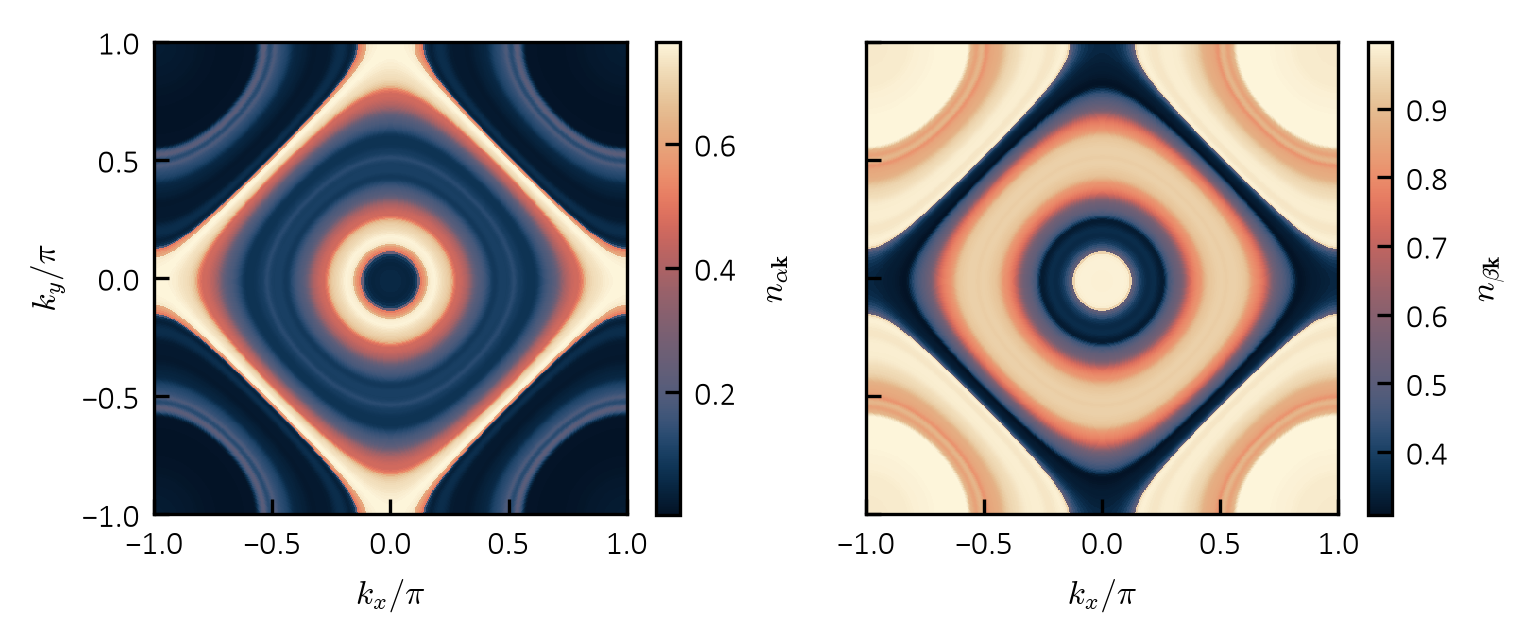

In [55]:
nk = 501
kk = np.linspace(-np.pi, np.pi, nk)
lab = sh.label(np.cos(kk)[:, None], np.cos(kk)[None, :])
nz = so.n[:, lab]

with pt.figure(shape=(1, 2), h=0.6, w=1.5, sharex=True, sharey=True) as fg:
    for nu, a in enumerate(fg.ax):
        im = color_map(a, kk / np.pi, kk / np.pi, nz[nu].T, cmap=cmaps.lipari)
        fg.colorbar(im, rf"$n_{{{bl[nu]}\mathbf{{k}}}}$", ax=a)
        format_ax(a, x=kk / np.pi, xlabel=r"$k_x/\pi$", grid=False)
        a.set_aspect("equal")
    fg.ax[0].set_ylabel(r"$k_y/\pi$")

[21:18:21] [INFO    ] T1/Tc = 2.900, T2/Tc = 1.000, T*/Tc = 1.000, T_fit/Tc = 5.213


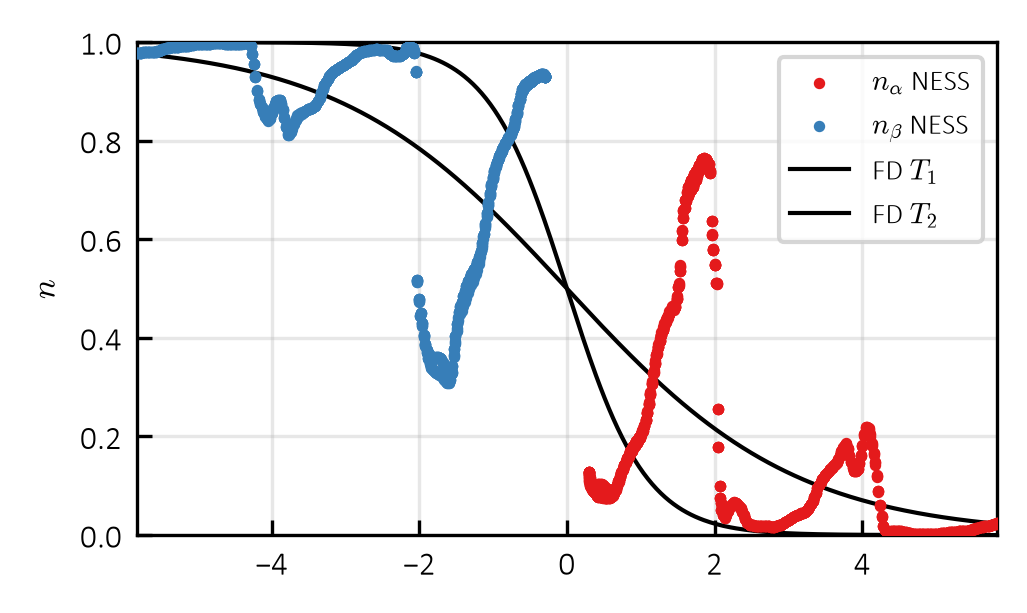

In [56]:
aw = kn[0].A.sum(axis=(1, 2))
w0 = W2                                     # energy where T* is marked


def t_star(eps, bb):
    """Temperature from the coupling weighted Bose factor at energy eps."""
    ws = [bt.amp * (spec_line(np, eps, bt.w0, bt.gam) if bt.gam > 0
                    else np.isclose(eps, bt.w0).astype(float)) for bt in bb]
    nm = sum(w / np.expm1(eps / bt.t) for w, bt in zip(ws, bb)) / sum(ws)
    return eps / np.log1p(1.0 / nm)


ts0 = float(t_star(np.array([w0]), bs)[0])

e2, m2 = so.e.ravel(), so.mu.ravel()
sw = np.sqrt(w2 * n * h)
cf = np.linalg.lstsq(np.stack((e2, np.ones_like(e2)), 1) * sw[:, None], m2 * sw,
                     rcond=None)[0]
tf, cfit = 1.0 / cf[0], -cf[1] / cf[0]

nb_ = getattr(sh, "nb", sh.ns)
de = np.gradient(so.e.reshape(2, -1, nb_), axis=-1).reshape(2, -1)
dm = np.gradient(so.mu.reshape(2, -1, nb_), axis=-1).reshape(2, -1)
good = (np.abs(de) > 0.05 * np.abs(de).max(axis=1, keepdims=True)) & (np.abs(so.mu) < 40.0)
tl = np.where(good & (np.abs(dm) > 0), de / np.where(dm != 0, dm, 1.0), np.nan)
logger.info("T1/Tc = %.3f, T2/Tc = %.3f, T*/Tc = %.3f, T_fit/Tc = %.3f",
            t1 / tc, t2 / tc, ts0 / tc, tf / tc)

xe = np.linspace(so.e.min(), so.e.max(), 400)

tls = [(t_, lb_, c_, chem_pot(so.e, sh.w, p.n, t_)) for t_, lb_, c_ in
       ((t1, r"$T_1$", "k"), (t2, r"$T_2$", "k"))]

with pt.figure(shape=(1, 1), h=0.6, sharex=True) as fg:
    a = fg.ax
    for nu in range(2):
        a.scatter(so.e[nu] / d0, so.n[nu], s=3, color=SET1_LIST[nu],
                  label=rf"$n_{{{bl[nu]}}}$ NESS", zorder=3)
    for t_, lb_, c_, mc in tls:
        a.plot(xe / d0, expit(-(xe - mc) / t_), color=c_, lw=1.0, label=rf"FD {lb_}")
    format_ax(a, x=xe / d0, ylabel=r"$n$", ylim=(0.0, 1.0))
    add_legend(a, top=False, ncol=1, fontsize=7)

    # a = fg.ax[1]
    # for nu in range(2):
    #     a.scatter(so.e[nu] / d0, tl[nu] / tc, s=6, color=SET1_LIST[nu],
    #               label=rf"$T_{{\mathrm{{loc}}}}$, ${bl[nu]}$", zorder=3)
    # for t_, _, c_, _ in tls:
    #     a.axhline(t_ / tc, color=c_, lw=1.0, ls="--")
    # format_ax(a, x=xe / d0, xlabel=r"$E/\Delta_0$", ylabel=r"$T/T_c$")
    # add_legend(a, ncol=2, fontsize=7)
    # fg.layout((0, 0, 1, 0.97))

In [57]:
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize

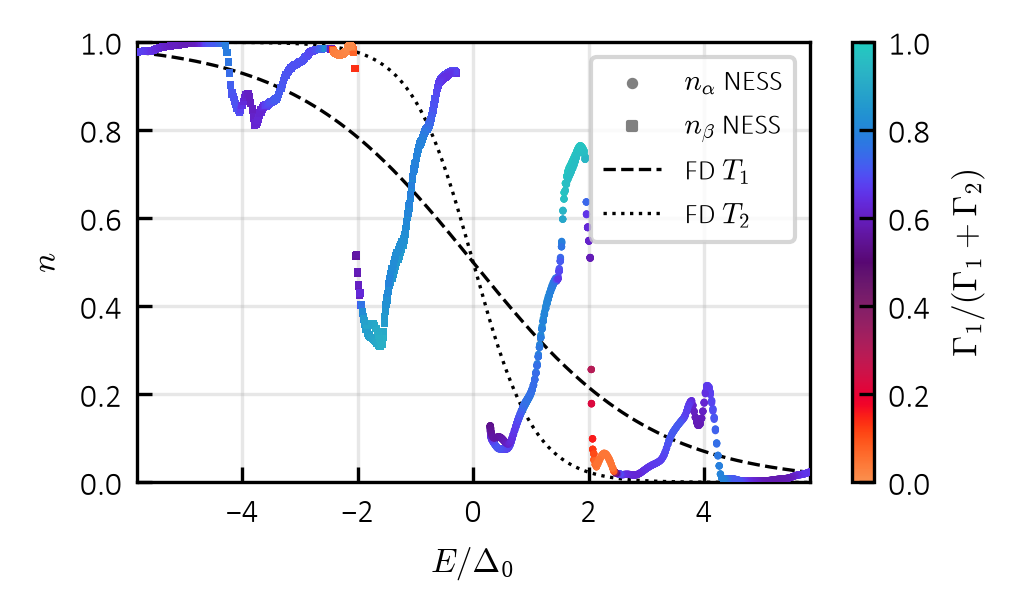

In [58]:
# transition rate per state from each bath separately (in + out)
gb = []
for bt, kt_ in zip(bs, kn):
    Kb = rates(cl, (bt,), (kt_,))
    gb.append(((h * (Kb @ n) + n * (Kb.T @ h)) / w2).reshape(2, sh.ns))
g1, g2 = gb
rb = np.where(g1 + g2 > 0, g1 / np.where(g1 + g2 > 0, g1 + g2, 1.0), np.nan)
rn = Normalize(0.0, 1.0)
cmr = cmaps.guppy                          

xe = np.linspace(so.e.min(), so.e.max(), 400)
tls = [(t_, lb_, ls_, chem_pot(so.e, sh.w, p.n, t_)) for t_, lb_, ls_ in
       ((t1, r"$T_1$", "--"), (t2, r"$T_2$", ":"))]
mks = ("o", "s")

with pt.figure(h=0.6) as fg:
    a = fg.ax
    for nu in range(2):
        im = a.scatter(so.e[nu] / d0, so.n[nu], s=3, c=rb[nu], cmap=cmr, norm=rn,
                       marker=mks[nu], edgecolors="none", zorder=3)
        a.scatter([], [], s=3, color="0.5", marker=mks[nu], label=rf"$n_{{{bl[nu]}}}$ NESS")
    for t_, lb_, ls_, mc in tls:
        a.plot(xe / d0, expit(-(xe - mc) / t_), color="k", ls=ls_, lw=0.8,
               label=rf"FD {lb_}")
    format_ax(a, x=xe / d0, xlabel=r"$E/\Delta_0$", ylabel=r"$n$", ylim=(0.0, 1.0))
    add_legend(a, fontsize=7)
    fg.colorbar(im, r"$\Gamma_1/(\Gamma_1+\Gamma_2)$", ax=a)

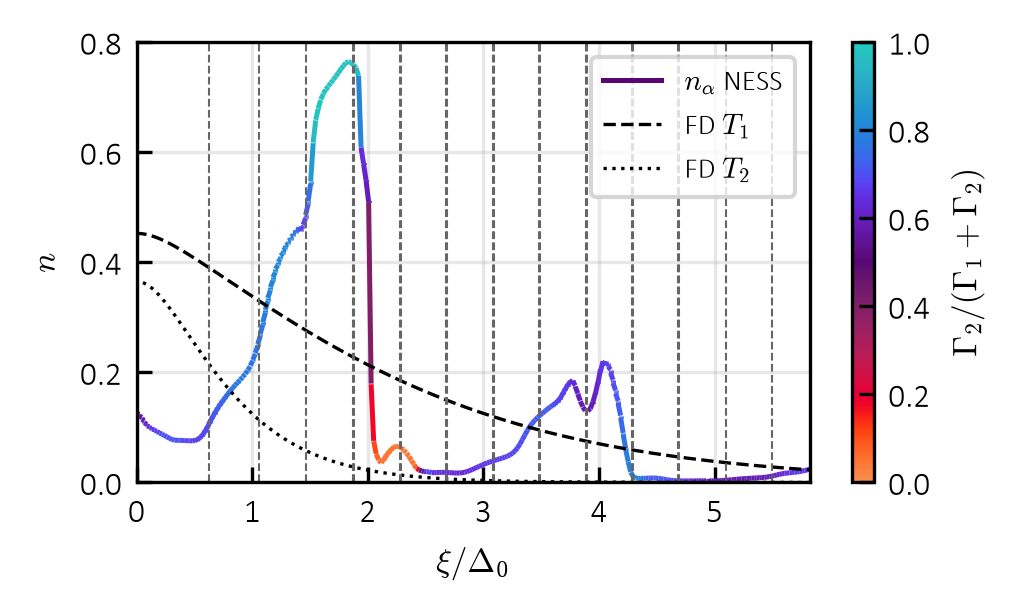

In [59]:
from matplotlib.collections import LineCollection

_, (ha_, hb_), _ = bands(sh.sc, so.d, so.m)
xi = 0.5 * (ha_ - hb_)                      # cell xi, same for all sectors of a shell
o = np.argsort(xi, kind="stable")


def cline(a, x, y, c, lw=1.2):
    """Line through (x, y), segment i coloured by the mean of c[i], c[i + 1]."""
    xy = np.stack((x, y), -1)
    lc = LineCollection(np.stack((xy[:-1], xy[1:]), 1), cmap=cmr, norm=rn, lw=lw)
    lc.set_array(np.ma.masked_invalid(0.5 * (c[:-1] + c[1:])))
    a.add_collection(lc)
    return lc

dq = W1 - W2                                 # pump step
k_ = np.arange(0, 12)
Ea = np.concatenate((so.d + dq * k_, -so.d + W1 + dq * k_))   # anchored at +-Delta
Ea = Ea[Ea > so.d]

with pt.figure(h=0.6) as fg:
    a = fg.ax
    for nu in range(1):
        im = cline(a, xi[o] / d0, so.n[nu][o], rb[nu][o])
        a.plot([], [], color=cmr(0.5), lw=1.2, label=rf"$n_{{{bl[nu]}}}$ NESS")
    for t_, lb_, ls_, mc in tls:
        for nu in range(1):
            a.plot(xi[o] / d0, expit(-(so.e[nu][o] - mc) / t_), color="k", ls=ls_,
                   lw=0.8, label=rf"FD {lb_}" if nu == 0 else None)
    for x_ in np.sqrt(Ea**2 - so.d**2) / d0:
        a.axvline(x_, color="0.4", ls="--", lw=0.5)
    format_ax(a, x=(0.0, xi.max() / d0), xlabel=r"$\xi/\Delta_0$",
              ylabel=r"$n$", ylim=(0.0, 0.8))
    L=np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    # a.vlines(0.2 + L * 0.4, 0.0, 0.8, colors="k", lw=0.5, linestyles="--")
    add_legend(a, fontsize=7, loc=1)
    fg.colorbar(im, r"$\Gamma_2/(\Gamma_1+\Gamma_2)$", ax=a)

In [60]:
print(t1 /tc, t2 /tc)
print(so.d, so.branch)
sn_ = SOLVE(sh, bd, p, bs, A=kn, normal=True)
print(so.d, so.branch, "| normal: ok", sn_.ok, "pair_chi", eb.pair_chi(sh, bd, p, sn_))

2.9 1.0
0.2958476001581834 ordered
0.2958476001581834 ordered | normal: ok True pair_chi 1.0114279497678504


In [61]:
sh = eb.make_sectors(55, NT)
kn = eb.kernels(sh, bd, bths(tc, tc), cache=ROOT / "kernels")  # one Kern per bath

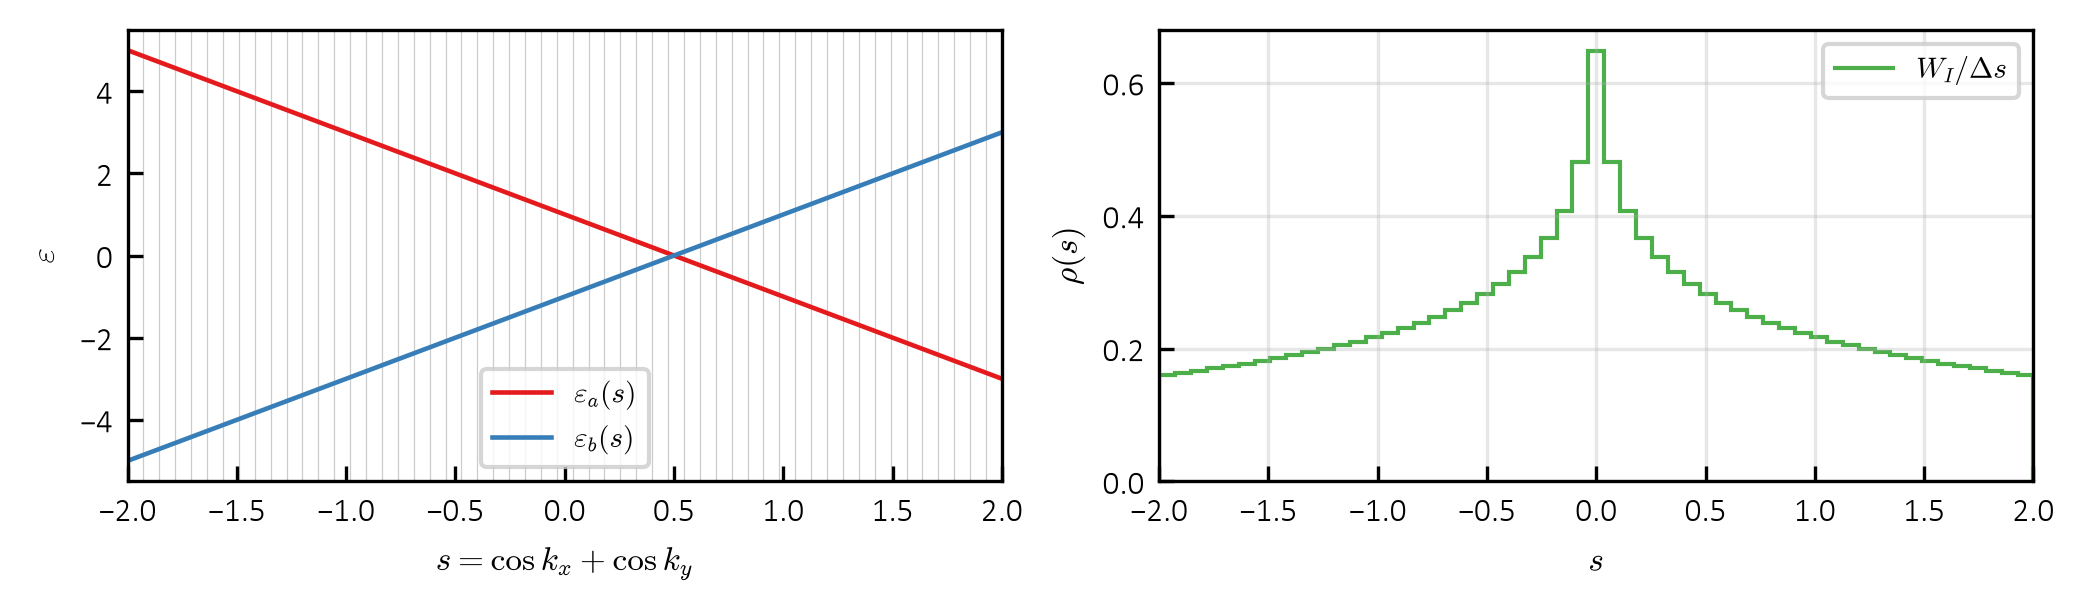

In [62]:
from EI_bins.kernel import cells

nb_ = getattr(sh, "nb", sh.ns)               # number of shells (sector grids too)
se_ = sh.se                                  # shell edges in s
ws_ = sh.w.reshape(-1, nb_).sum(0)           # shell weights (summed over sectors)
sf = np.linspace(-2.0, 2.0, 2001)
ea, eb_ = bd.bare(sf)

with pt.figure(shape=(1, 2), h=0.6, w=2.0) as fg:
    a = fg.ax[0]
    a.plot(sf, ea, color=SET1_LIST[0], lw=1.1, label=r"$\varepsilon_a(s)$")
    a.plot(sf, eb_, color=SET1_LIST[1], lw=1.1, label=r"$\varepsilon_b(s)$")
    for x_ in se_:
        a.axvline(x_, color="0.8", lw=0.3, zorder=0)     # bin edges in s
    format_ax(a, x=sf, xlabel=r"$s=\cos k_x+\cos k_y$", ylabel=r"$\varepsilon$", grid=False)
    add_legend(a, fontsize=7)

    a = fg.ax[1]
    a.stairs(ws_ / np.diff(se_), se_, color=SET1_LIST[2], lw=1.0, label=r"$W_I/\Delta s$")
    format_ax(a, x=se_, xlabel=r"$s$", ylabel=r"$\rho(s)$")
    add_legend(a, fontsize=7)

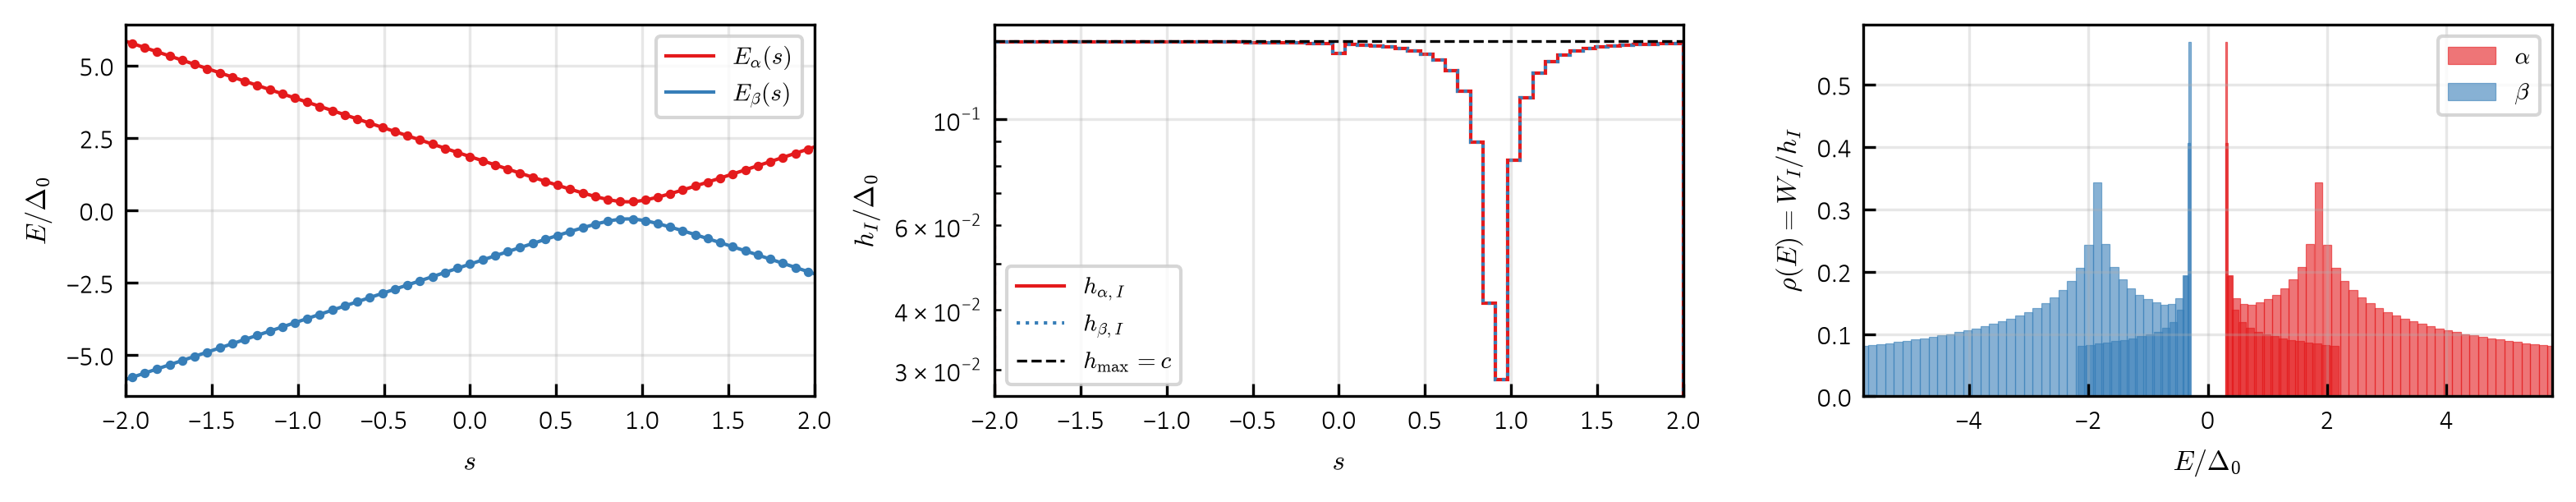

In [63]:
cl = cells(sh, bd, p, so.d, so.m)
_, _, (qa, qb) = bands(sf, so.d, so.m)
hmax = bd.slope * (se_[1] - se_[0])          # largest cell width in E

with pt.figure(shape=(1, 3), h=0.6, w=3.0) as fg:
    a = fg.ax[0]
    for nu, q_ in enumerate((qa, qb)):
        a.plot(sf, q_ / d0, color=SET1_LIST[nu], lw=1.0, label=rf"$E_{{{bl[nu]}}}(s)$")
        a.scatter(sh.sc[:nb_], cl.e[nu, :nb_] / d0, s=3, color=SET1_LIST[nu], zorder=3)
    format_ax(a, x=sf, xlabel=r"$s$", ylabel=r"$E/\Delta_0$")
    add_legend(a, fontsize=7)

    a = fg.ax[1]
    for nu, ls_ in ((0, "-"), (1, ":")):
        a.stairs(cl.hw[nu, :nb_] / d0, se_, color=SET1_LIST[nu], lw=1.0, ls=ls_,
                 label=rf"$h_{{{bl[nu]},I}}$")
    a.axhline(hmax / d0, color="k", ls="--", lw=0.8, label=r"$h_{\max}=c$")
    a.set_yscale("log")
    format_ax(a, x=se_, xlabel=r"$s$", ylabel=r"$h_I/\Delta_0$")
    add_legend(a, fontsize=7)

    a = fg.ax[2]                              # DOS in E: one bar per cell, width h_I
    for nu in range(2):
        a.bar(cl.e[nu, :nb_] / d0, ws_ / cl.hw[nu, :nb_] * d0,
              width=cl.hw[nu, :nb_] / d0, color=SET1_LIST[nu], alpha=0.6,
              edgecolor=SET1_LIST[nu], lw=0.3, label=rf"${bl[nu]}$")
    xr_ = (cl.e[:, :nb_].min() / d0, cl.e[:, :nb_].max() / d0)
    format_ax(a, x=xr_, xlabel=r"$E/\Delta_0$", ylabel=r"$\rho(E)=W_I/h_I$")
    add_legend(a, fontsize=7)